In [101]:
import pandas as pd
import ast
import re

In [126]:
with open("suggest-units1-dorpout1-activationl1_6.txt", "r") as file:
    lines = [line.strip() for line in file if "prune" not in line]
    lines = lines[1:]
    # lines = [line.strip().split(":", 3)[3] for line in lines]
    # lines = [line.strip().rsplit(".", 3)[0] for line in lines]
    # lines = [line.strip().split(":", 1) for line in lines]
    # lines = [line[0].strip().split(" ", 1)[0] for line in lines]

In [127]:
logs = lines.copy()

# Extract values using regex
data = []
for log in logs:
    value_match = re.search(r"finished with value: ([\d\.]+)", log)  # Extract value
    params_match = re.search(r"parameters: ({.*?})", log)  # Extract dictionary

    if value_match and params_match:
        value = float(value_match.group(1))  # Convert to float
        params = ast.literal_eval(params_match.group(1))  # Convert string dict to real dict
        data.append({"val_accuracy": value, **params})  # Merge dicts

# Convert to DataFrame
df = pd.DataFrame(data).sort_values(["val_accuracy"],ascending=False)
df.to_excel("suggest-units1-dorpout1-activationl1_6.xlsx", index=False)

display(df)

,val_accuracy,n_units_l0,dropout_l0,n_units_l1,dropout_l1,learning_rate
57,0.902038,108,0.308773,76,0.281958,0.000027
51,0.900962,98,0.233589,72,0.219196,0.000035
82,0.900885,100,0.220281,58,0.246491,0.000033
49,0.899615,99,0.207752,70,0.273161,0.000030
29,0.899269,98,0.233260,56,0.247671,0.000029
...,...,...,...,...,...,...
2,0.852808,82,0.250234,40,0.266734,0.000087
9,0.851308,78,0.265079,36,0.397800,0.000017
24,0.841885,97,0.289432,39,0.277620,0.000010
8,0.839346,76,0.262103,38,0.492726,0.000021


In [35]:
import urllib
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

try:
    import numpy as np
except ImportError as e:
    error = str(e)
    lib = error.split()[-1].replace("'", "")
    print(f"\033[32mIntalling {lib}\033[0m")
    !pip install numpy==2.1.3
    import numpy as np

try:
    import matplotlib.pyplot as plt
except ImportError as e:
    error = str(e)
    lib = error.split()[-1].replace("'", "")
    print(f"\033[32mIntalling {lib}\033[0m")
    !pip install matplotlib==3.10.0
    import matplotlib.pyplot as plt

try:
    import sklearn
    import sklearn.datasets
    import sklearn.linear_model
    from sklearn.model_selection import train_test_split
except ImportError as e:
    error = str(e)
    lib = error.split()[-1].replace("'", "")
    print(f"\033[32mIntalling {lib}\033[0m")
    !pip install scikit-learn==1.6.1
    import sklearn
    import sklearn.datasets
    import sklearn.linear_model
    from sklearn.model_selection import train_test_split

try:
    import h5py
except ImportError as e:
    error = str(e)
    lib = error.split()[-1].replace("'", "")
    print(f"\033[32mIntalling {lib}\033[0m")
    !pip install h5py==3.13.0
    import h5py

try:
    import optuna
    from optuna.trial import TrialState
except ImportError as e:
    error = str(e)
    lib = error.split()[-1].replace("'", "")
    print(f"\033[32mIntalling {lib}\033[0m")
    !pip install optuna==4.2.1
    import optuna
    from optuna.trial import TrialState

try:
    from optuna.integration import KerasPruningCallback
except ImportError as e:
    error = str(e)
    lib = error.split()[-1].replace("'", "")
    print(f"\033[32mIntalling {lib}\033[0m")
    !pip install optuna-integration[keras]==4.2.1
    from optuna.integration import KerasPruningCallback

try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras import layers
except ImportError as e:
    error = str(e)
    lib = error.split()[-1].replace("'", "")
    print(f"\033[32mIntalling {lib}\033[0m")
    !pip install tensorflow==2.19.0
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras import layers
    
try:
    import keras
    from keras.utils import to_categorical
    from keras.layers import Dense
    from keras.layers import Dropout
    from keras.models import Sequential
    from keras.optimizers import RMSprop
except ImportError as e:
    error = str(e)
    lib = error.split()[-1].replace("'", "")
    print(f"\033[32mIntalling {lib}\033[0m")
    !pip install keras==3.9.0
    import keras
    from keras.utils import to_categorical
    from keras.layers import Dense
    from keras.layers import Dropout
    from keras.models import Sequential
    from keras.optimizers import RMSprop

%matplotlib inline

In [36]:
from ImportImagenes_mod import *
SEED = 42
CE_x, CV_x, CE_y, CV_y = import_imagenes()
CE_x, CV_x, CE_y, CV_y = CE_x.T, CV_x.T, CE_y.T, CV_y.T
print("\nEntrenamiento 200 aumentado:")
print("CE_x shape:\n", CE_x.shape)
print("CE_y shape:\n", CE_y.shape)

print("\nValidación:")
print("CV_x shape:\n", CV_x.shape)
print("CV_y shape:\n", CV_y.shape)


Dimensión de X_train: (14700, 2600)
Dimensión de X_test: (14700, 50)
Dimensión de y_train: (1, 2600)
Dimensión de y_test: (1, 50)

Entrenamiento 200 aumentado:
CE_x shape:
 (2600, 14700)
CE_y shape:
 (2600, 1)

Validación:
CV_x shape:
 (50, 14700)
CV_y shape:
 (50, 1)


In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay,accuracy_score

{'n_layers': 3, 'activation_l0': 'selu', 'n_units_l0': 5, 'dropout_l0': 0.420178915490353, 'activation_l1': 'selu', 'n_units_l1': 13, 'dropout_l1': 0.4489642579418174, 'activation_l2': 'elu', 'n_units_l2': 24, 'dropout_l2': 0.40270447178276747}

{'n_layers': 3, 'activation_l0': 'elu', 'n_units_l0': 9, 'dropout_l0': 0.3592689284415138, 'activation_l1': 'selu', 'n_units_l1': 12, 'dropout_l1': 0.4448910232012121, 'activation_l2': 'elu', 'n_units_l2': 21, 'dropout_l2': 0.2883524527808368, 'learning_rate': 4.7390206742505655e-05}
Last Epoch: 150
Last Training Accuracy: 0.9000
Last Validation Accuracy: 0.8600

0.8633846104145049 and parameters: {'n_layers': 2, 'activation_l0': 'elu', 'n_units_l0': 6, 'dropout_l0': 0.2868088815453722, 'activation_l1': 'elu', 'n_units_l1': 16, 'dropout_l1': 0.20505103389280682, 'learning_rate': 5.37398798756962e-05}
Epoch 83/133
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8841 - loss: 0.3411 - val_accuracy: 0.9200 - val_loss: 0.2754

0.8751153767108917 and parameters: {'n_layers': 2, 'activation_l0': 'elu', 'n_units_l0': 7, 'dropout_l0': 0.28028039733002263, 'activation_l1': 'elu', 'n_units_l1': 19, 'dropout_l1': 0.20669032313428332, 'learning_rate': 6.689344561093338e-05}. Best is trial 97 with value: 0.8751153767108917.
Epoch 132/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9049 - loss: 0.2750 - val_accuracy: 0.9000 - val_loss: 0.2641

0.8904615223407744 and parameters: {'activation_l0': 'leaky_relu', 'n_units_l0': 88, 'dropout_l0': 0.33630347783559533, 'activation_l1': 'leaky_relu', 'n_units_l1': 56, 'dropout_l1': 0.43312734761328786, 'learning_rate': 2.6119474276204012e-05}
Epoch 117/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9254 - loss: 0.2227 - val_accuracy: 0.9400 - val_loss: 0.2528

0.8960384786128996 and parameters: {'n_units_l0': 99, 'dropout_l0': 0.30748172670516327, 'n_units_l1': 37, 'dropout_l1': 0.23604484228443118, 'learning_rate': 6.362050247649443e-05}
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9469 - loss: 0.1675 - val_accuracy: 0.8400 - val_loss: 0.3170
Epoch 98/150

0.9009615540504454 and parameters: {'n_units_l0': 98, 'dropout_l0': 0.23358925980239428, 'n_units_l1': 72, 'dropout_l1': 0.2191963886074372, 'learning_rate': 3.533426167502112e-05}
Epoch 92/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9375 - loss: 0.1887 - val_accuracy: 0.9400 - val_loss: 0.2637

0.9020384728908537 and parameters: {'n_units_l0': 108, 'dropout_l0': 0.3087725007496074, 'n_units_l1': 76, 'dropout_l1': 0.28195796475963886, 'learning_rate': 2.745518225857252e-05}
Epoch 119/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9421 - loss: 0.1879 - val_accuracy: 0.9400 - val_loss: 0.2421

0.9025769114494322 and parameters: {'n_units_l0': 111, 'dropout_l0': 0.21837633172142518, 'n_units_l1': 72, 'dropout_l1': 0.3518212264364254, 'learning_rate': 3.284837571498211e-05}
Epoch 84/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9272 - loss: 0.2139 - val_accuracy: 0.9400 - val_loss: 0.2535

0.8948269173502923 and parameters: {'n_units_l0': 85, 'dropout_l0': 0.39824402846536955, 'n_units_l1': 53, 'dropout_l1': 0.24517347442851, 'learning_rate': 5.522689061838563e-05}

In [128]:
# params = best_trial.params
# n_layers = params["n_layers"]

act_l0 = "leaky_relu"
num_hidden_l0 = 111
dropout_l0 = 0.21837633172142518
act_l1 = "leaky_relu"
num_hidden_l1 = 72
dropout_l1 = 0.3518212264364254
# act_l2 = "elu"
# num_hidden_l2 = 21
# dropout_l2 = 0.2883524527808368
# act_l3 = "selu"
# num_hidden_l3 = 52
# dropout_l3 = 0.4192143260056905
learning_rate = 3.284837571498211e-05

checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    "model_checkpoint_epoch_{epoch:02d}.weights.h5",  # Save weights with epoch number
    save_weights_only=True,  # Saves only weights, not full model
    save_freq="epoch"  # Saves at every epoch
)


# The data is split between train and validation sets.
(x_train, y_train), (x_valid, y_valid) = (CE_x, CE_y), (CV_x, CV_y)
x_train = x_train.astype("float32")
x_valid = x_valid.astype("float32")

# Convert class vectors to binary class matrices.
y_train = to_categorical(y_train, 2)
y_valid = to_categorical(y_valid, 2)

# Clear clutter from previous session graphs.
keras.backend.clear_session()

# We define our MLP.
model_cp = Sequential()

model_cp.add(Dense(num_hidden_l0, activation=act_l0))
model_cp.add(Dropout(rate=dropout_l0))


model_cp.add(Dense(num_hidden_l1, activation=act_l1))
model_cp.add(Dropout(rate=dropout_l1))

# model_cp.add(Dense(num_hidden_l2, activation=act_l2))
# model_cp.add(Dropout(rate=dropout_l2))


model_cp.add(Dense(2, activation="sigmoid"))

model_cp.compile(
        loss="binary_crossentropy",
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        metrics=["accuracy"],
    )
history = model_cp.fit(
        x_train,
        y_train,
        batch_size=100,
        callbacks=[checkpoint_callback], #KerasPruningCallback(trial, "val_accuracy"), early_stopping_callback
        epochs=150,
        validation_data=(x_valid, y_valid),
        verbose=1
        # shuffle=True
    )



Epoch 1/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.5513 - loss: 0.7111 - val_accuracy: 0.8200 - val_loss: 0.5841
Epoch 2/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6807 - loss: 0.6316 - val_accuracy: 0.6600 - val_loss: 0.5892
Epoch 3/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7351 - loss: 0.5853 - val_accuracy: 0.7600 - val_loss: 0.4763
Epoch 4/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7657 - loss: 0.5406 - val_accuracy: 0.8800 - val_loss: 0.4262
Epoch 5/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7860 - loss: 0.5081 - val_accuracy: 0.8600 - val_loss: 0.3871
Epoch 6/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7793 - loss: 0.5190 - val_accuracy: 0.7800 - val_loss: 0.4134
Epoch 7/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7838 - loss: 0.4946 - val_accuracy: 0.8400 - val_loss: 0.4105
Epoch 8/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7932 - loss: 0.4792 - val_accuracy: 0.

Epoch 84 Training Accuracy: 0.9296
Epoch 84 Validation Accuracy: 0.9400


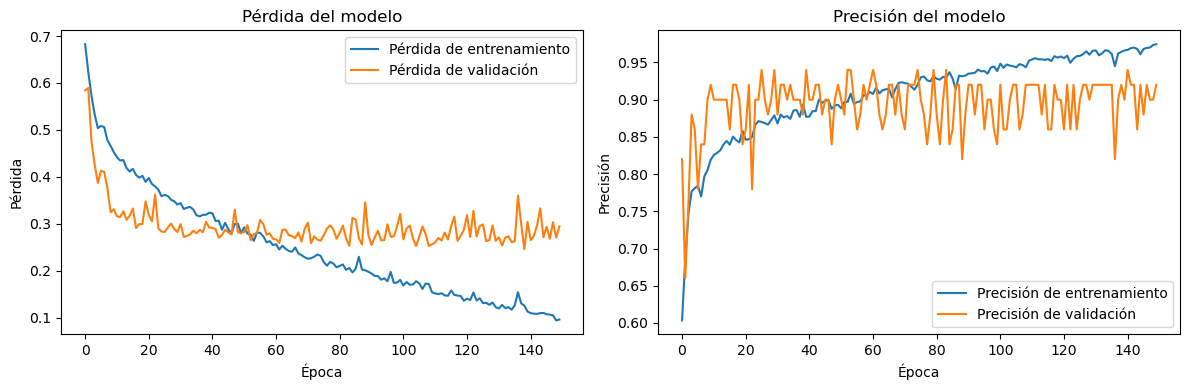

ValueError: Classification metrics can't handle a mix of multilabel-indicator and binary targets

In [129]:
epoch_10 = 84  # Specify the epoch number you want

model_cp.load_weights(f"model_checkpoint_epoch_{epoch_10}.weights.h5")

# Get accuracy values at epoch 10 (index 9 because Python is 0-based)
train_accuracy_epoch_10 = history.history["accuracy"][epoch_10 - 1]
val_accuracy_epoch_10 = history.history["val_accuracy"][epoch_10 - 1]

print(f"Epoch {epoch_10} Training Accuracy: {train_accuracy_epoch_10:.4f}")
print(f"Epoch {epoch_10} Validation Accuracy: {val_accuracy_epoch_10:.4f}")


plt.figure(figsize=(12, 4))
 
# Gráfico de pérdida
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Pérdida de entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida de validación')
plt.title('Pérdida del modelo')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
 
# Gráfico de precisión
plt.subplot(1, 2, 2)
if 'accuracy' in history.history:
    plt.plot(history.history['accuracy'], label='Precisión de entrenamiento')
    plt.plot(history.history['val_accuracy'], label='Precisión de validación')
    plt.title('Precisión del modelo')
    plt.xlabel('Época')
    plt.ylabel('Precisión')
    plt.legend()
elif 'acc' in history.history:
    plt.plot(history.history['acc'], label='Precisión de entrenamiento')
    plt.plot(history.history['val_acc'], label='Precisión de validación')
    plt.title('Precisión del modelo')
    plt.xlabel('Época')
    plt.ylabel('Precisión')
    plt.legend()
 
plt.tight_layout()
plt.show()

y_pred_probs = model_cp.predict(x_valid, verbose=0)  
y_pred = np.argmax(y_pred_probs, axis=1)

y_pred_probs_t = model_cp.predict(x_train, verbose=0)  
y_pred_t = np.argmax(y_pred_probs_t, axis=1)

# y_valid = np.argmax(y_valid, axis=1)
cm = confusion_matrix(y_valid, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
 
plt.show() 

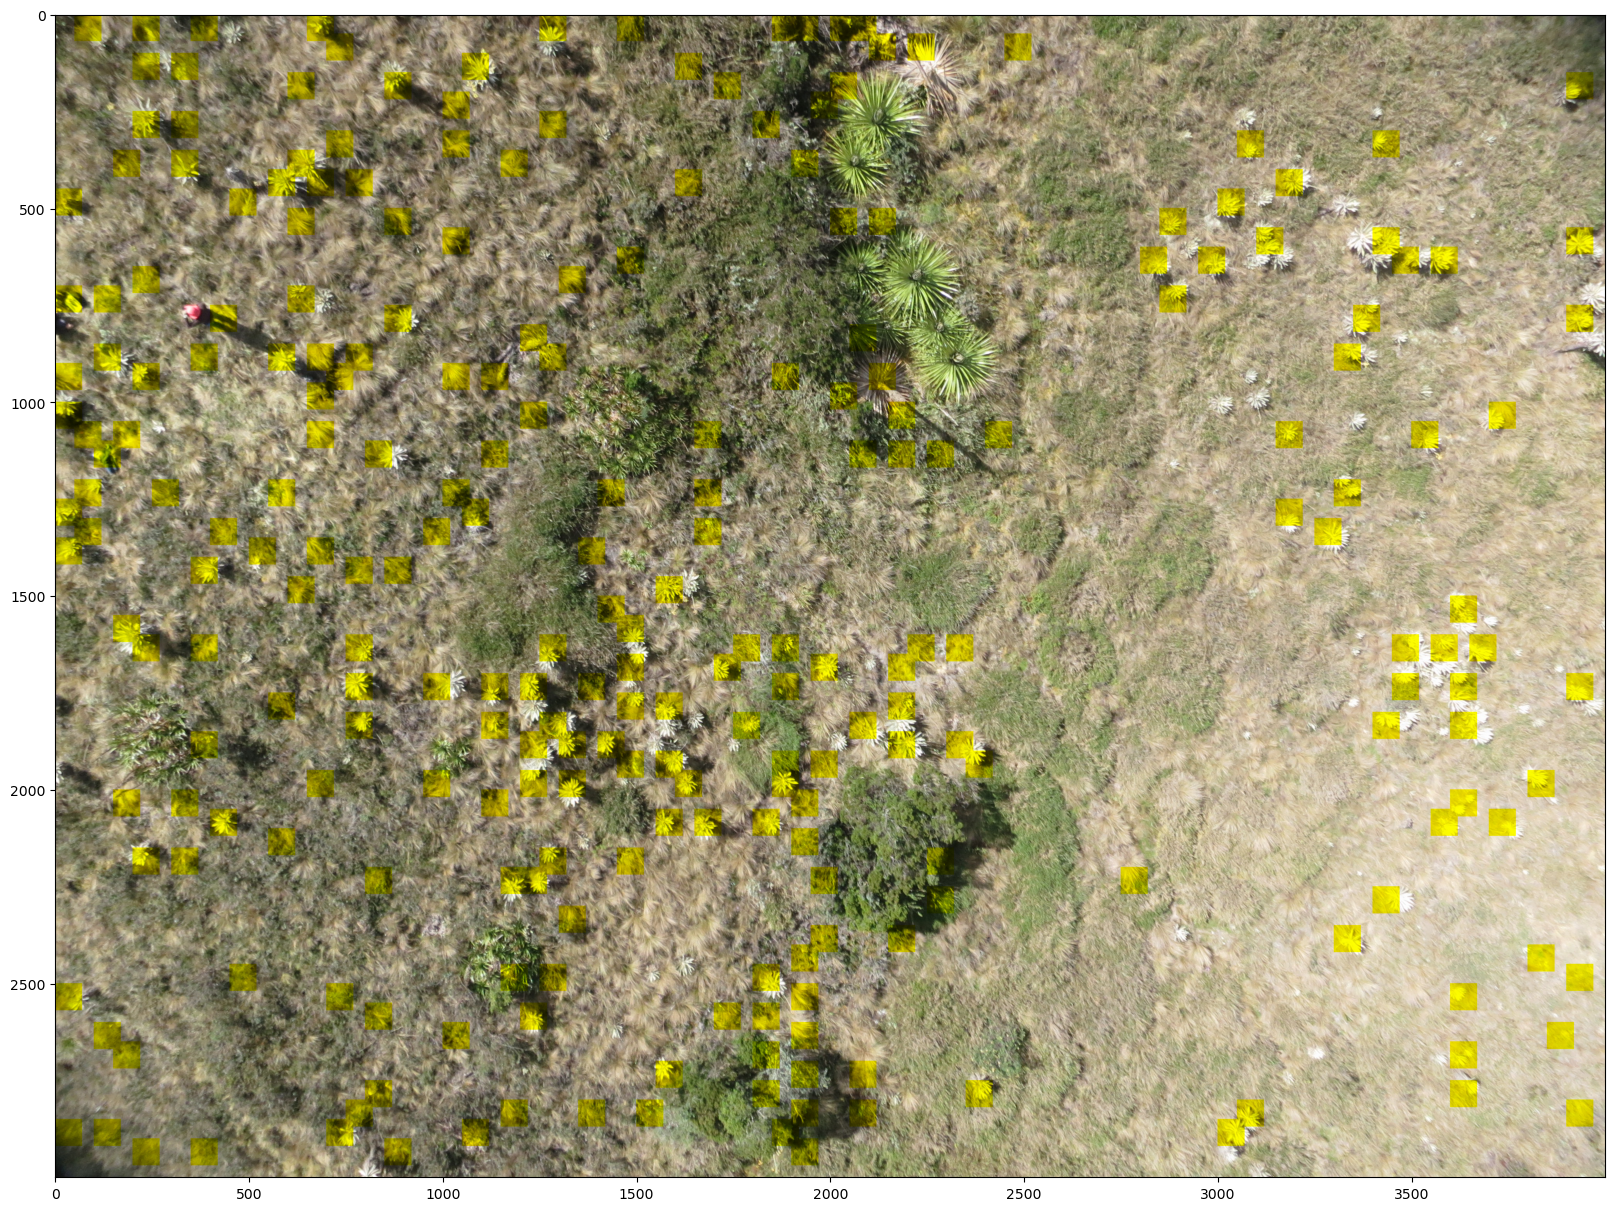

In [113]:
from tensorflow.keras.utils import load_img
urllib.request.urlretrieve('https://github.com/sergiomora03/AdvancedTopicsAnalytics/blob/main/notebooks/img/IMG_3451.JPG?raw=true', 'IMG_3451.JPG')
img = load_img('IMG_3451.JPG')
img = np.array(img)  
# Lo pasamos por nuestra imagen de prueba
x = np.array(img)
x2 = x

ni = x.shape[0]-50
mi = x.shape[1]-50

f1=0
f2=70
for i in range(1,ni,50):
    c1=0
    c2=70
    for j in range(1,mi,50):
        subi=x[f1:f2,c1:c2,]
        subi2=np.ndarray.flatten(subi).T/255.
        ns=subi2.shape[0]
        vec=subi2
        vec.shape=(ns,1)
        pred_P=np.argmax(model_cp.predict(vec.T, verbose=0), axis=1)
        if(pred_P==1):
            x2[f1:f2,c1:c2,2]=0
        c1=c1+50
        c2=c2+50
    f1=f1+50
    f2=f2+50

plt.figure(figsize = (20,20))
plt.imshow(x2)